# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

In [1]:
## YOUR CODE HERE
import pandas as pd
df = pd.read_csv('../data/keywords_data.csv')
df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file. 
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In [2]:
## YOUR CODE HERE
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Extract and preprocess keywords (lowercase only)
keyword_cols = [f'Keyword {i}' for i in range(1, 13)]
keyword_df = df[keyword_cols].dropna(how='all') # Only delete the row if every single value in the selected columns is missing

# Collect keywords from all docs, which can be considered as tokens
all_docs_keywords = []
for index, row in keyword_df.iterrows():
    # Drop NaNs and convert to lowercase as requested
    keywords = row.dropna().astype(str).str.lower().str.strip().tolist()
    if keywords:
        all_docs_keywords.append(keywords)

# Generate Co-Occurrence Pairs
co_occurrence_pairs = list()
for tokens in all_docs_keywords:
    filtered_tokens = sorted(set(tokens)) # Sort the words, the co-occurrence may not be treated as uni-directional
    co_occurrence_pairs += [(filtered_tokens[i], filtered_tokens[j]) for i in range(len(filtered_tokens)) for j in range(i + 1, len(filtered_tokens))]
print(f"➡ co_occurrence_pairs: {co_occurrence_pairs[:50]}...")

# Weigh
weighted_co_occurrences = nltk.FreqDist(co_occurrence_pairs) #FreDist is simply BoW, which counts the appearance of tokens
print(f"➡ weighted_co_occurrences: {weighted_co_occurrences.most_common(10)}...")

# Create The Adjacency Matrix
unique_keywords = sorted(list(set(word for pair in weighted_co_occurrences.keys() for word in pair)))
adj_matrix = pd.DataFrame(0, index=unique_keywords, columns=unique_keywords) # Create an empty matrix
for (word1, word2), weight in weighted_co_occurrences.items(): # Fill the matrix using the FreqDist data
    adj_matrix.at[word1, word2] = weight
    adj_matrix.at[word2, word1] = weight

# Verify symmetry
is_symmetric = (adj_matrix.values == adj_matrix.T.values).all()
print(f"Is matrix symmetric? {is_symmetric}")
adj_matrix.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tuong\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tuong\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


➡ co_occurrence_pairs: [('agency theory', 'corporate governance'), ('agency theory', 'equity'), ('agency theory', 'financial performance'), ('agency theory', 'meta-analysis'), ('agency theory', 'organizational behavior'), ('agency theory', 'organizational effectiveness'), ('agency theory', 'organizational research'), ('agency theory', 'organizational sociology'), ('agency theory', 'performance'), ('agency theory', 'psychometrics'), ('corporate governance', 'equity'), ('corporate governance', 'financial performance'), ('corporate governance', 'meta-analysis'), ('corporate governance', 'organizational behavior'), ('corporate governance', 'organizational effectiveness'), ('corporate governance', 'organizational research'), ('corporate governance', 'organizational sociology'), ('corporate governance', 'performance'), ('corporate governance', 'psychometrics'), ('equity', 'financial performance'), ('equity', 'meta-analysis'), ('equity', 'organizational behavior'), ('equity', 'organizational 

,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises,...,violence in the workplace,wage payment systems,wages,women -- employment,women employees,work & family,work attitudes,work environment,work environment -- psychological aspects,workflow
agency theory,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,2,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network

Number of nodes: 248
Number of edges: 2141


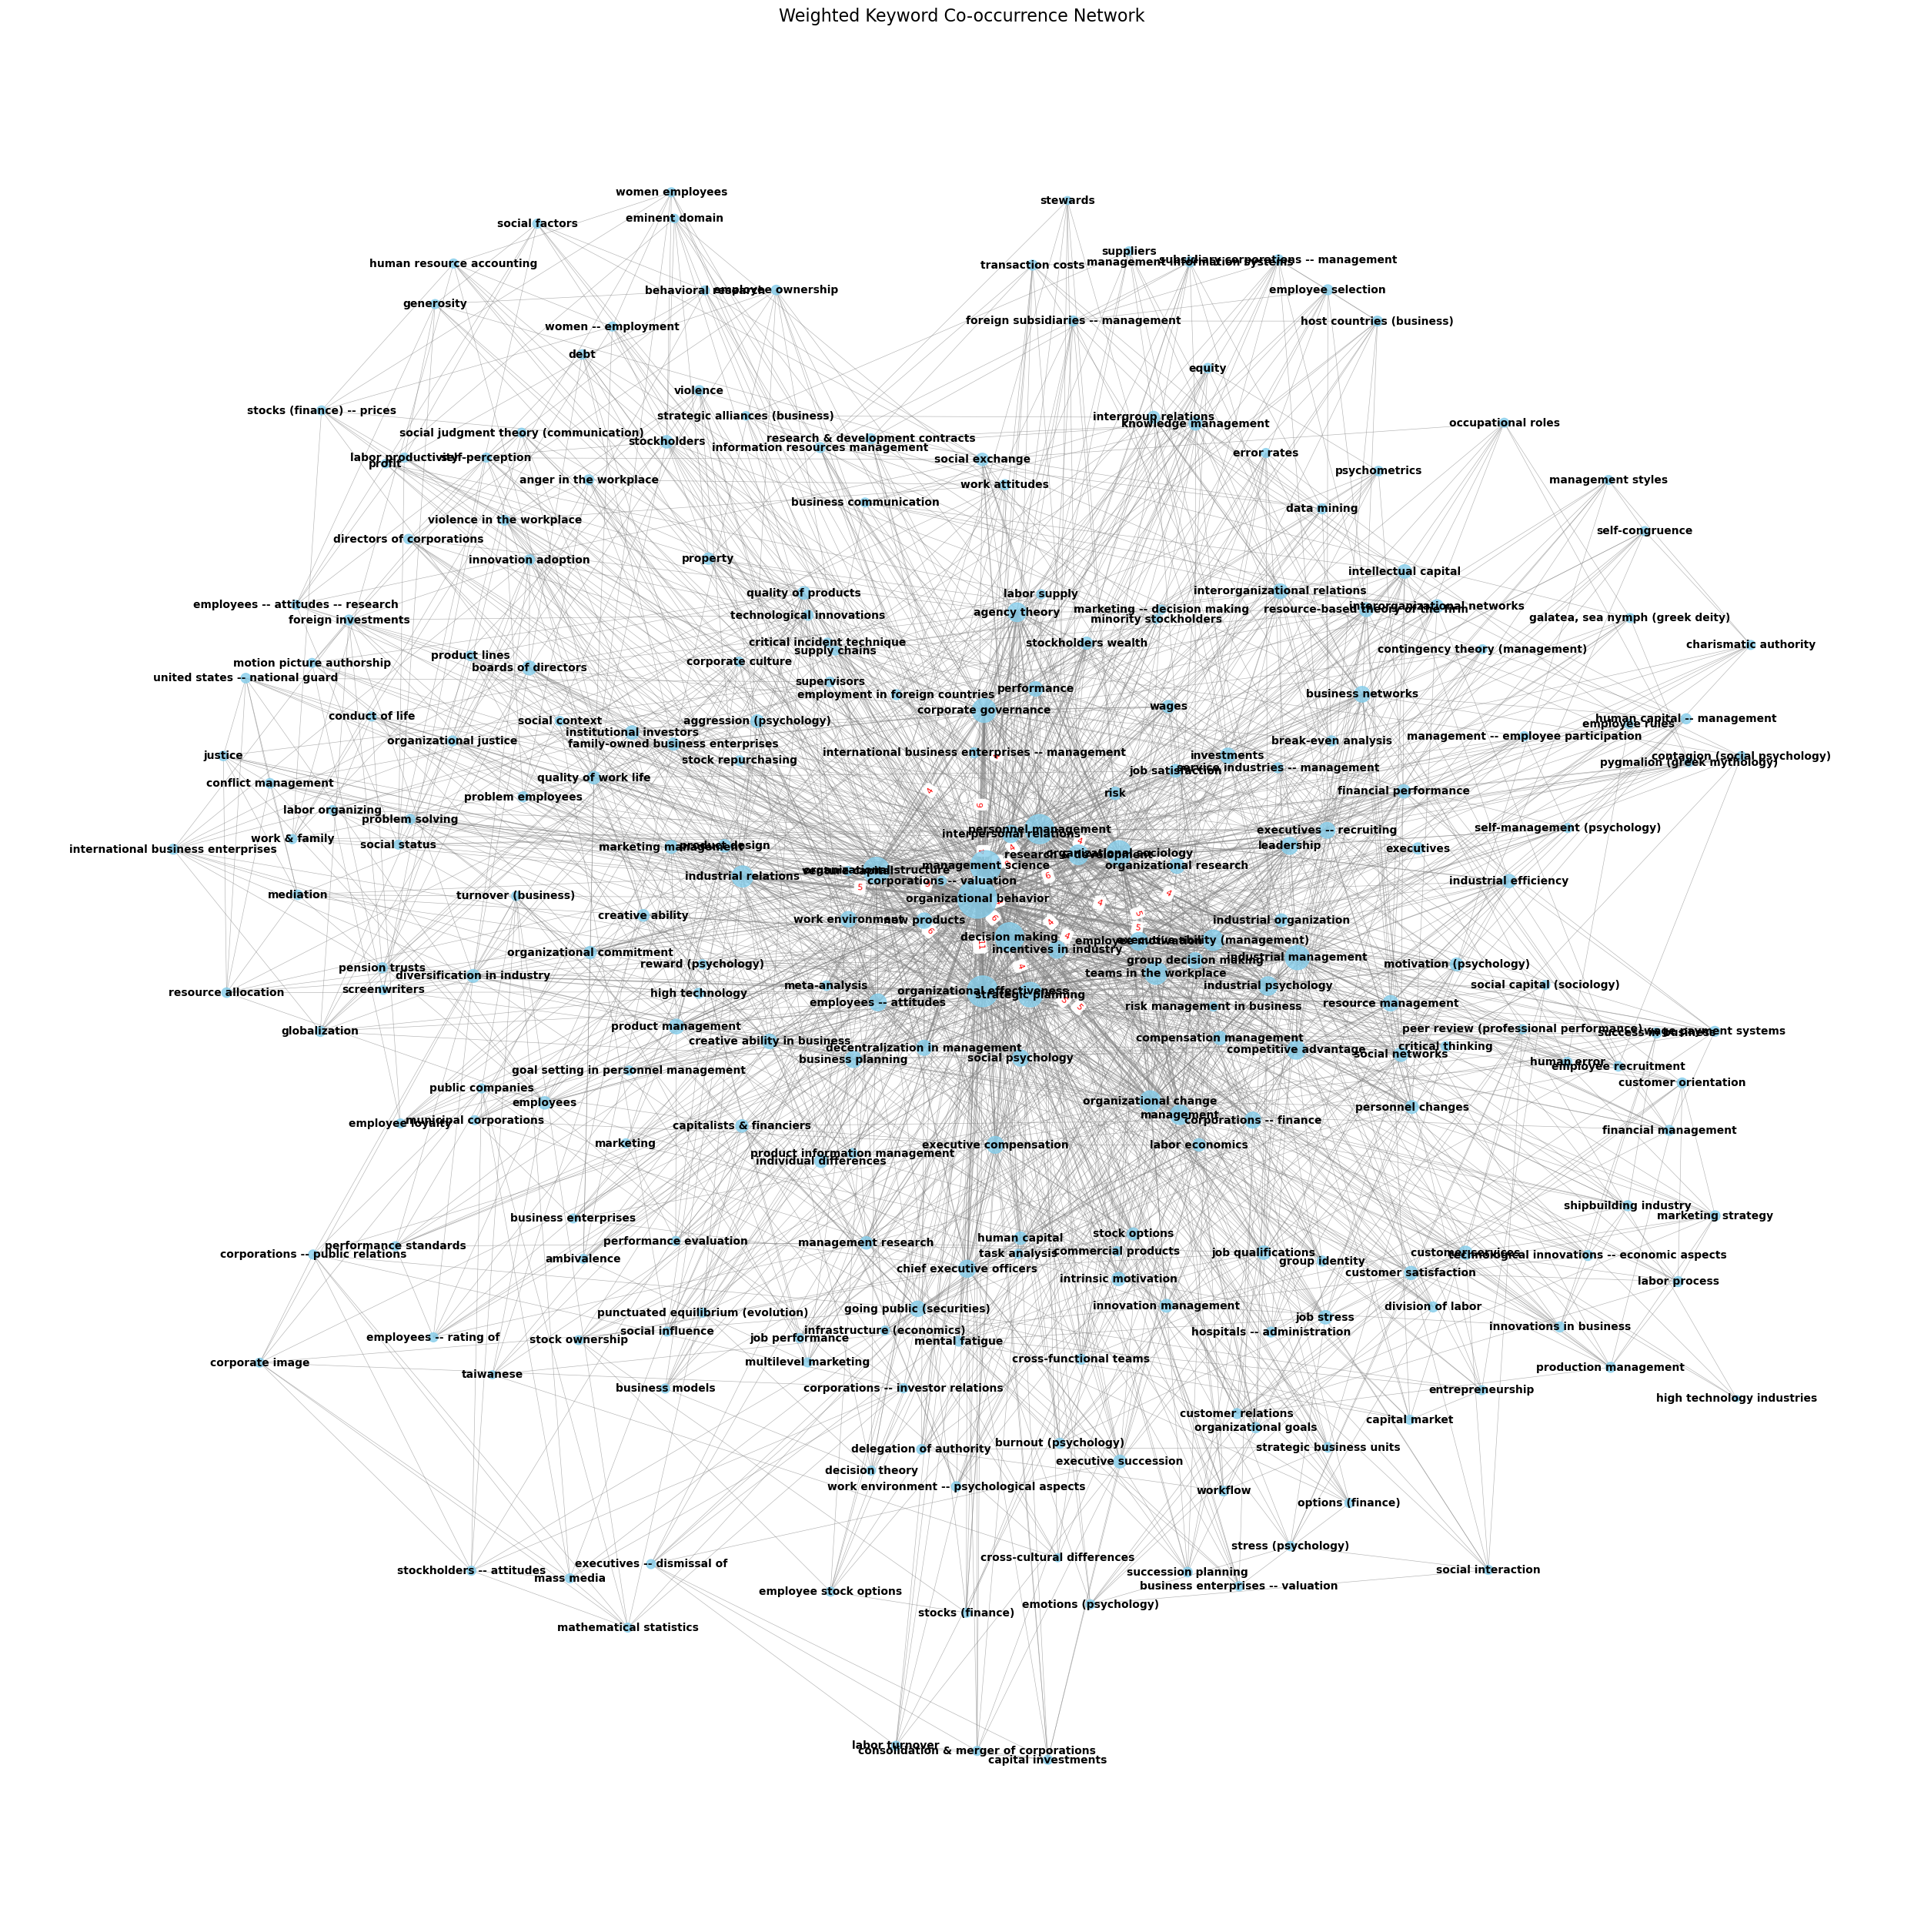

In [3]:
## YOUR CODE HERE
import networkx as nx
import matplotlib.pyplot as plt

# >>> Build the weighted co-occurrence network
G = nx.from_pandas_adjacency(adj_matrix)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
# G = nx.Graph()
# for (word1, word2), weight in weighted_co_occurrences.items(): #Just generate the graph
#     if G.has_edge(word1, word2): #when considering (cat,a), if there was (a,cat) in graph, we will increase the weight w(a,cat) += w(cat,a)
#         G[word1][word2]['weight'] += weight
#     else:
#         G.add_edge(word1, word2, weight=weight)


# >>> Customized weighted graph visualization
plt.figure(figsize=(32, 32))
pos = nx.spring_layout(G, k=0.7, seed=42)  # Set seed for reproducibility, 'k' increases the distance between nodes; higher = more spread out

node_degrees = dict(G.degree())
node_sizes = [v * 8 for v in node_degrees.values()] # Size nodes based on their number of connections
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

edge_weights = [data['weight'] for _, _, data in G.edges(data=True)] 
edge_weights_normalized = [weight / max(edge_weights) * 5 for weight in edge_weights] # Normalize to use for setting the line color, thick
nx.draw_networkx_edges(G, pos, edge_color='gray', width=edge_weights_normalized, alpha=0.6)

nx.draw_networkx_labels(G, pos, font_size=10, font_color='black', font_weight='bold')

edge_labels = {(word1, word2): f'{weight}' for (word1, word2, weight) in G.edges(data='weight') if weight > 3} # Label only if weight > 3
nx.draw_networkx_edge_labels(G, pos, font_size=8, edge_labels=edge_labels, font_color='red')

plt.title("Weighted Keyword Co-occurrence Network", fontsize=16)
plt.axis('off')
plt.savefig('../outputs/weighted_keyword_co-occurrence_network.png', dpi=300, bbox_inches='tight')
plt.show()

### **Task 4:**  Compute node degree and strength

In [4]:
## YOUR CODE HERE
# Flatten the list for Pandas
weighted_pairs_data = []
for (k1, k2), weight in weighted_co_occurrences.items():
    weighted_pairs_data.append({'keyword1': k1, 'keyword2': k2, 'weight': weight})
    # Since co-occurrence is undirected, we add the reverse to count for both keywords, then only need to use groupby() for the first column
    weighted_pairs_data.append({'keyword1': k2, 'keyword2': k1, 'weight': weight})
weighted_pairs_df = pd.DataFrame(weighted_pairs_data)
print(weighted_pairs_df.head())

# Compute degree and strength
degree_df = weighted_pairs_df.groupby('keyword1')['keyword2'].nunique().to_dict() # Degree: Count unique neighbors
strength_df = weighted_pairs_df.groupby('keyword1')['weight'].sum().to_dict() # Strength: Sum the weights

# Uses built-in functions for verification
degree_dict = dict(G.degree()) # Node Degree
strength_dict = dict(G.degree(weight='weight')) # Compute Node Strength (Weighted Degree)

if degree_df == degree_dict and strength_df == strength_dict:
    print(">> Verification Passed")
else:
    print(">> Verification Failed")

# Combine into a DataFrame for analysis
stats_df = pd.DataFrame({
    'Keyword': degree_df.keys(),
    'Degree': degree_df.values(),
    'Strength': strength_df.values()
})

stats_df.head()

               keyword1               keyword2  weight
0         agency theory   corporate governance       3
1  corporate governance          agency theory       3
2         agency theory                 equity       1
3                equity          agency theory       1
4         agency theory  financial performance       1
>> Verification Passed


,Keyword,Degree,Strength
0,agency theory,38,48
1,aggression (psychology),18,20
2,ambivalence,9,9
3,anger in the workplace,11,11
4,behavioral research,9,9


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

In [5]:
## YOUR CODE HERE
# Display Top 10 by Degree
print("--- Top 10 by Degree ---")
print(stats_df.sort_values(by='Degree', ascending=False).head(10))

# Display Top 10 by Strength
print("\n--- Top 10 by Strength ---")
print(stats_df.sort_values(by='Strength', ascending=False).head(10))

--- Top 10 by Degree ---
                          Keyword  Degree  Strength
154       organizational behavior     166       265
157  organizational effectiveness     104       144
135            management science     102       136
169          personnel management      93       126
47                decision making      90       112
162      organizational structure      74       107
161      organizational sociology      66        96
220            strategic planning      66        80
99          industrial management      64        84
28           corporate governance      62        85

--- Top 10 by Strength ---
                          Keyword  Degree  Strength
154       organizational behavior     166       265
157  organizational effectiveness     104       144
135            management science     102       136
169          personnel management      93       126
47                decision making      90       112
162      organizational structure      74       107
161      or

### **Task 6:** Show the top 10 node pairs by weight

In [6]:
# Extract unique edges with their weights (undirected)
edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]

# Combine into a DataFrame for analysis
pairs_df = pd.DataFrame(edges, columns=['keyword 1', 'keyword 2', 'weight'])
pairs_df = pairs_df.sort_values(by='weight', ascending=False).reset_index(drop=True) # Sort by Weight descending and show top 10
pairs_df.head(10)

,keyword 1,keyword 2,weight
0,organizational behavior,organizational effectiveness,11
1,organizational behavior,organizational structure,9
2,organizational behavior,personnel management,8
3,management science,organizational behavior,7
4,organizational effectiveness,organizational structure,6
5,organizational behavior,organizational sociology,6
6,decision making,organizational behavior,6
7,corporate governance,organizational behavior,6
8,organizational sociology,teams in the workplace,5
9,industrial management,organizational behavior,5


### **Task 7:** Plot strength on y-axis and degree on x-axis

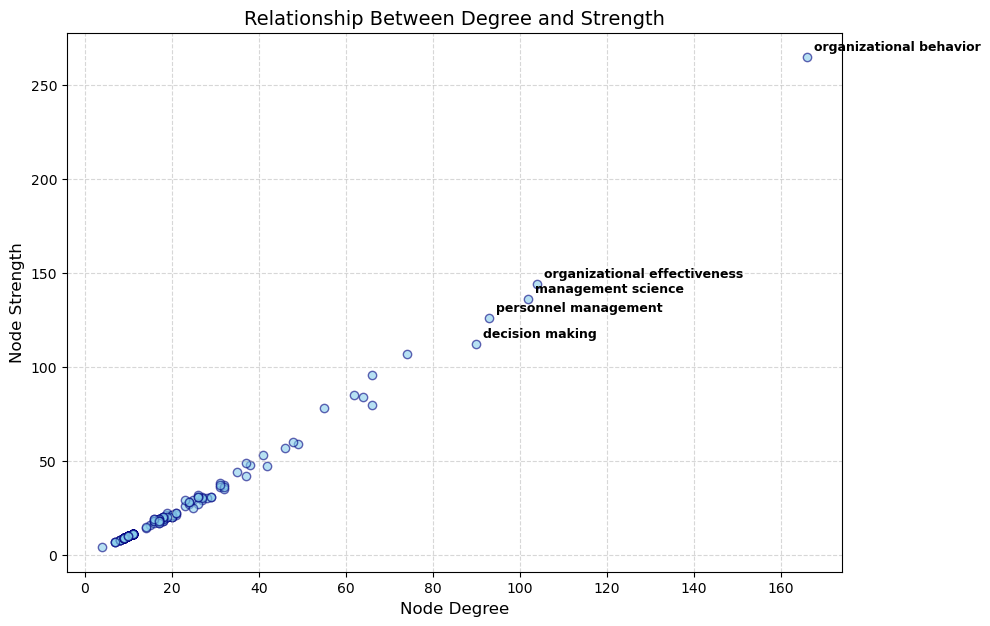

In [7]:
## YOUR CODE HERE
plt.figure(figsize=(10, 7))
plt.scatter(stats_df['Degree'], stats_df['Strength'], 
            color='skyblue', alpha=0.6, edgecolors='navy', label='Keywords')

top_hubs = stats_df.sort_values(by='Strength', ascending=False).head(5)
for i, row in top_hubs.iterrows():
    plt.annotate(row['Keyword'], (row['Degree'], row['Strength']), xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold')

plt.xlabel('Node Degree', fontsize=12)
plt.ylabel('Node Strength', fontsize=12)
plt.title('Relationship Between Degree and Strength', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('../outputs/relationship_between_degree_and_strength.png', dpi=300, bbox_inches='tight')
plt.show()

- It is almost perfectly linear relationship between degree and strength. The correlation is nearly 1.0.
- Organizational Behavior is at the extreme top-right of your plot. With a Degree of 166 and a Strength of 265, any path through this network likely passes through this node.

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook 
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!